In [1]:
# Import all needed libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Download MNIST Datasets
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
# Precprocess dataset
X_train = X_train.reshape((-1,28,28,1))/255.0
X_test = X_test.reshape((-1,28,28,1))/255.0
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [4]:
# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation = 'relu', input_shape = (28,28,1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3),activation = 'relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation = 'relu'),
    Dense(10, activation = 'softmax')
])

c:\Users\marth\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Compile and train the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=128, epochs=10, validation_data=(X_test,y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.8374 - loss: 0.5694 - val_accuracy: 0.9795 - val_loss: 0.0683
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9801 - loss: 0.0659 - val_accuracy: 0.9864 - val_loss: 0.0422
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9859 - loss: 0.0477 - val_accuracy: 0.9872 - val_loss: 0.0390
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9888 - loss: 0.0360 - val_accuracy: 0.9874 - val_loss: 0.0370
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9909 - loss: 0.0289 - val_accuracy: 0.9885 - val_loss: 0.0367
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9923 - loss: 0.0243 - val_accuracy: 0.9881 - val_loss: 0.0353
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9941 - loss: 0.0185 - val_accuracy: 0.9894 - val_loss: 0.0312
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9950 - loss: 0.0161 - 

In [6]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9894 - loss: 0.0437
Test Loss: 0.0322
Test Accuracy: 0.9922


In [7]:
# Select random images from the test
random_indexes = np.random.choice(len(X_test), size = 5, replace=False)
images = X_test[random_indexes]
true_labels = np.argmax(y_test[random_indexes], axis=1)

In [8]:
# Make predictions using the trained model
predictions = np.argmax(model.predict(images), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

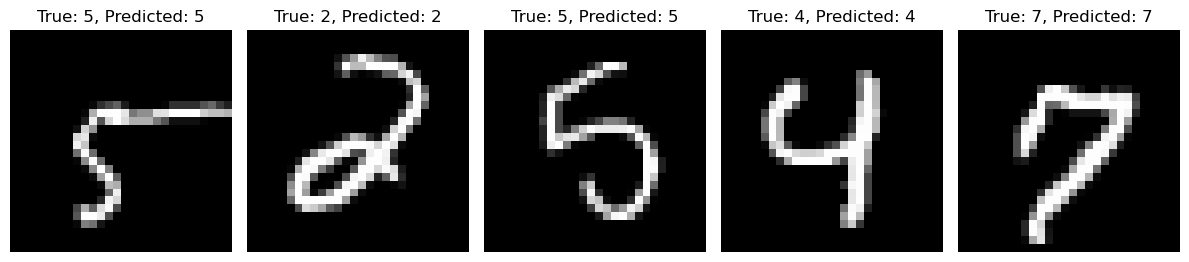

In [9]:
# Depict images, their model predictions and their true label
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for i, (image, true_label, predicted_label) in enumerate(zip(images, true_labels, predictions)):
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f'True: {true_label}, Predicted: {predicted_label}')
    axes[i].axis('off')
    
plt.tight_layout()
plt.show